In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_csv('shopping_trends_with_brands.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases,Brand
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly,Gap
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly,New Balance
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly,Adidas
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly,Puma
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually,Burberry


In [ ]:
df.shape

(3900, 20)

In [ ]:
df.dtypes

Customer ID                   int64
Age                           int64
Gender                          str
Item Purchased                  str
Category                        str
Purchase Amount (USD)         int64
Location                        str
Size                            str
Color                           str
Season                          str
Review Rating               float64
Subscription Status             str
Payment Method                  str
Shipping Type                   str
Discount Applied                str
Promo Code Used                 str
Previous Purchases            int64
Preferred Payment Method        str
Frequency of Purchases          str
Brand                           str
dtype: object

In [ ]:
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
Brand                       0
dtype: int64

In [ ]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


 2. **EXPLORATORY DATA ANALYSIS**


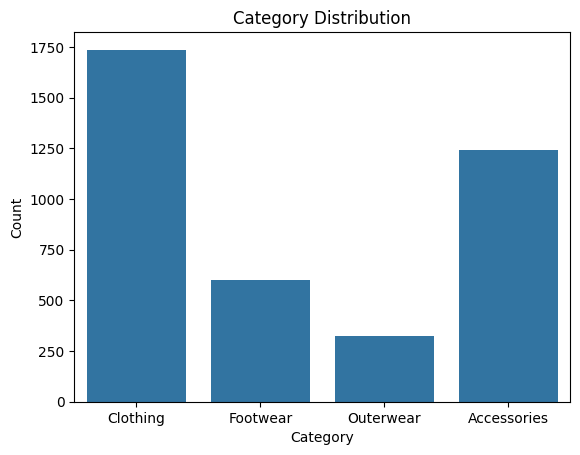

In [ ]:
sns.countplot(x='Category', data=df)
plt.title('Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

AGE DISTRIBUTION OF CUSTOMERS


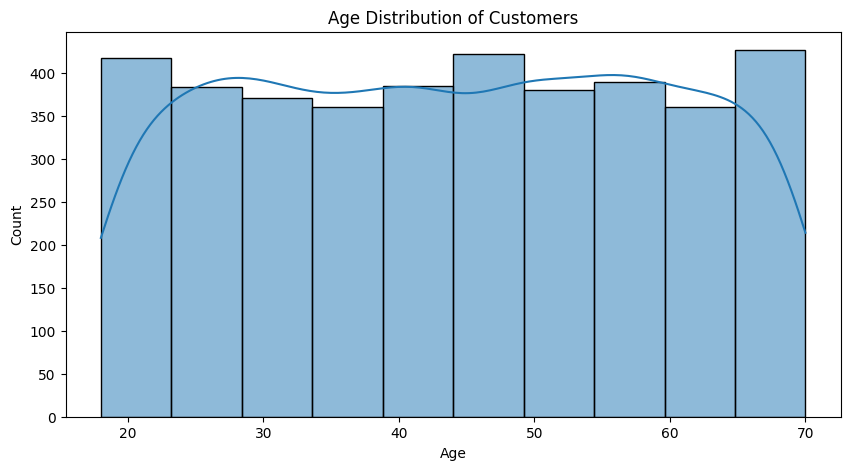

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['Age'], bins=10, kde=True)
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

CATEGORY PURCHASES BY SEASON

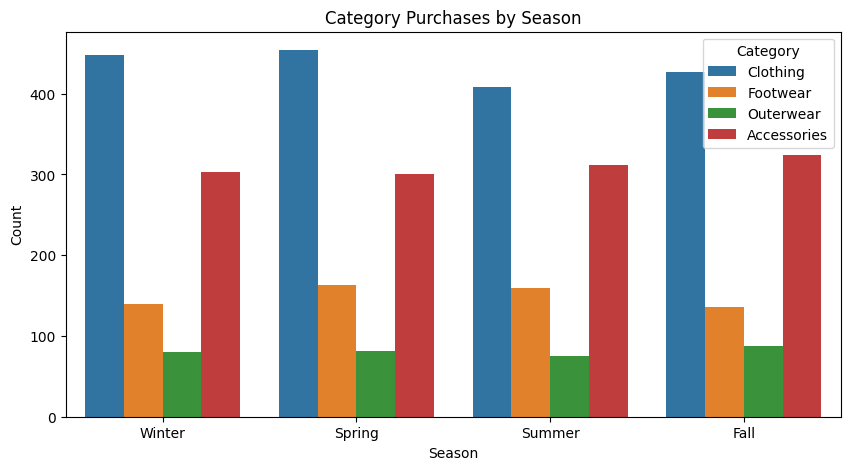

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='Season', hue='Category', data=df)
plt.title('Category Purchases by Season')
plt.xlabel('Season')
plt.ylabel('Count')
plt.legend(title='Category')
plt.show()

PURCHASE AMOUNT BY CATEGORY


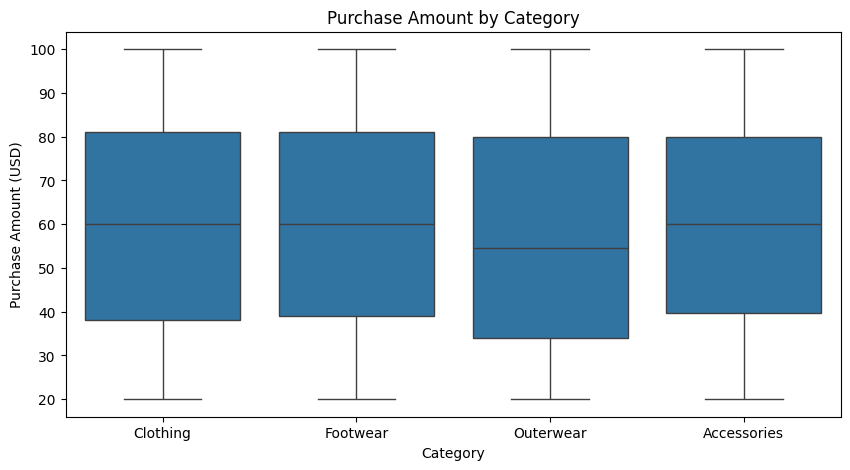

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Category', y='Purchase Amount (USD)', data=df)
plt.title('Purchase Amount by Category')
plt.xlabel('Category')
plt.ylabel('Purchase Amount (USD)')
plt.show()

3. **PREPROCESSING**



In [ ]:
X = df.drop(columns=['Category'])
y = df['Category']

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include='str').columns:
    X[col] = le.fit_transform(X[col])

In [ ]:
X.head()

,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases,Brand
0,55,1,2,53,16,0,7,3,3.1,1,2,1,1,1,14,5,3,6
1,19,1,23,64,18,0,12,3,3.1,1,0,1,1,1,2,1,3,11
2,50,1,11,73,20,2,12,1,3.1,1,1,2,1,1,23,2,6,0
3,21,1,14,90,38,1,12,1,3.5,1,4,3,1,1,49,4,6,13
4,45,1,2,49,36,1,21,1,2.7,1,1,2,1,1,31,4,0,2


In [ ]:
X = X.drop(columns=['Customer ID'])

In [ ]:
y = le.fit_transform(y)

In [ ]:
print(y)

[1 1 1 ... 0 2 0]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

 4. **MODEL BUILDING AND TRAINING**


In [ ]:
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Accessories', 'Clothing', 'Footwear', 'Outerwear']))

0.8256410256410256
              precision    recall  f1-score   support

 Accessories       0.89      0.81      0.85       249
    Clothing       0.76      0.95      0.84       346
    Footwear       0.93      0.54      0.68       122
   Outerwear       1.00      0.76      0.86        63

    accuracy                           0.83       780
   macro avg       0.89      0.77      0.81       780
weighted avg       0.85      0.83      0.82       780



**STREAMLIT EXPORT**

In [ ]:
import joblib
joblib.dump(model, 'category_model.pkl')

['category_model.pkl']

In [ ]:
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

In [ ]:
from google.colab import files
files.download('category_model.pkl')
files.download('label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>